In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1749057517.355716   48112 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749057517.360569   48112 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749057517.373674   48112 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749057517.373699   48112 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749057517.373701   48112 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749057517.373703   48112 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 7: Working with Keras: A deep dive

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit, we are going to take a more detailed look at the Keras API.  A better understanding of some
of the details of the different `keras` workflows will help you to better understand the examples
and models we will develop in upcoming chapters.


## 7.1 A Spectrum of Workflows

The design of the Keras API is guided by the principle of progressive disclosure of complexity:
make it easy to get started, yet make it possible to handle high-complexity use cases. 
Simple use cases should be easy and approachable, and arbitrarily advanced workflows should be possible.
As such, there’s not a single “true” way of using Keras. Rather, Keras offers a spectrum
of workflows, from the very simple to the very flexible.

## 7.2 Different Ways to build Keras Models

There are three APis for building models in Keras:

1. The **Sequential model**, the most approachable API—it’s basically a Python list. As
   such, it’s limited to simple stacks of layers.
2. The **Functional API**, which focuses on graph-like model architectures. It represents
   a nice mid-point between usability and flexibility, and as such, it’s the
   most commonly used model-building API.
3. **Model subclassing**, a low-level option where you write everything yourself from
   scratch.

### 7.2.1 The Sequential model

The simplest way to build a Keras model is to use the `Sequential` model.  You should be pretty familiar
with simple sequential models at this point from our previous examples.

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

# a sequent model using the Sequential class,
# layers are actually just passed in as a list of layer objects here
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

Its possible to build the same model incrementially via the `add()` method, which is similar to
using `append()` to append items to the end of a Python `List`.

In [5]:
# this would be an equivalent model as the previous
# example, just built incrementally
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

We have seen that layers only get built when they are called for the first time.  That's
because the layers' weights depends on the shape of their input.  Until the input shape is known, they
can't be created.

As such, the preceeding Sequential model does not have any weights yet until you actually call it on some data or
call its `build()` method.

In [6]:
# internal may have changed from text, we don't see a value error if we access
# this object parameter, just an empty list.
model.weights

[]

But if we explicitly call `build()` and provide the initial input shape (in the following
there are no samples, but we specify 3 features come in as input) then we will have
a set of weights now for the model.

In [7]:
# by providing input shape the model can construct and initialze its weights
model.build(input_shape=(None, 3))

model.weights

I0000 00:00:1749057520.117096   48112 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


[<Variable path=sequential_1/dense_2/kernel, shape=(3, 64), dtype=float32, value=[[-0.2334 -0.2455  0.0153  0.1335  0.219   0.2185  0.2823  0.2297 -0.1256
   -0.2179 -0.0221 -0.1904 -0.0788  0.2057  0.0645 -0.1428  0.231   0.2387
    0.2024  0.0096 -0.0303 -0.0603  0.1492  0.1896  0.2748  0.2473 -0.247
   -0.151  -0.1605 -0.1683 -0.2574 -0.19   -0.2832  0.1111 -0.0051 -0.2747
   -0.1405 -0.1523  0.086   0.1562 -0.1003  0.1057  0.1154  0.2476  0.0078
   -0.2904 -0.1364 -0.1586 -0.2002 -0.2051  0.1226  0.0874  0.0875  0.2348
    0.1056 -0.2509  0.083  -0.0643 -0.2749 -0.0147  0.1577  0.1596 -0.0959
    0.1651]
  [-0.1522  0.1054  0.0213 -0.1955  0.1757 -0.0849  0.0194  0.1062  0.0655
    0.1283 -0.2948 -0.1548  0.0834  0.0491  0.0327 -0.2477 -0.1237 -0.0638
    0.0451  0.1192  0.1143 -0.2759  0.2949  0.2577  0.1636 -0.1218 -0.109
    0.1937 -0.1337 -0.1474 -0.173  -0.1499 -0.056   0.281   0.0358  0.0031
    0.2005  0.0583  0.1715 -0.1828 -0.0345 -0.0433 -0.295  -0.2395 -0.0781
   -0.1382

If you look closely, there are 3 sets of 64 tensors and 64 sets of 10 tensors for the two layers
respectively.  All of these weights have been initialized to small random values.  There are also
two sets of biases, one for each layer, initialized to all 0 values.

After a model is built, you can display its contents via the `summary()` method, which
comes in handy for debugging.

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

The names here like "sequential_2" for the model name or "dense_4" for the layer name are auto assigned by
Keras, but you can specify the names to give to layers and models (and everything) to help readabiity.

In [9]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_last_layer (Dense)           │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

It can be usefule when building a model incrementally to be able to print a summary of
what the model looks like after each layer is added.  But you can't print a summary until
the model is built!  But you can do this on the fly by declaring the shape of
the model's input in advance using the `Input` class, which you may
see used in some models.

In [10]:
model = keras.Sequential(name="my_example_model")
# use Input to declare the shape of the inputs.  Note that the shape argument
# muste be the shape of each single sample, not the shape of a batch, e.g. just
# a vector with the number of features of input to the first layer
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Now you can use `summary()` to follow how the layer shapes change as you add
more layers.

In [11]:
model.add(layers.Dense(10, activation="softmax", name="my_second_layer"))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_second_layer (Dense)         │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

This is a pretty common debugging workflow when dealing with layers that
transform their inputs in complex ways, such as convolutional layers.

Also notice the parameter counts given.  This can be useful to judge the size and thus
power of a model.  You should be able to figure out why these two dense layers have
the number of parameter indicated (e.g. for layer 1 we have 3x64 weights and 64
biases).

### 7.2.7 The Functional API

The `Sequential` model is easy to use, but its applicability is extremely limited.  It can only
be used to specify simple models with a single input and a single output, and applying the
tensor transformations one layer after the other in a sequential fashion.

As we will be looking at in the next few units, it's pretty common to encounter
models with multipe inputs, multiple outputs, or a nonlinear network graph.

In such cases you'd build your model using the **Functional API**.  This is what most
Keras models you'll encounter for non-trivial real-world problems will be using.

#### A simple example

Lets start with the stack of two layers we used in the previous example.  To create this
model using the Functional API do the following:

In [12]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

We started by declaring an `Input`.  This returns an instance object that we named `inputs`.
The `inputs` object holds information about the `shape` and `dtype` of the data that the
model will process.

In [13]:
# this model will process batches where each sample has shape (3,)
# number of samples per batch is variable, indicate by the None batch size
inputs.shape

(None, 3)

In [14]:
# These batches will have data type float32 (32 bit floating point value)
inputs.dtype

'float32'

We call such an object a **symbolic tensor**. It doesn't contain any actual data, but it
encodes the specifications of the actual tensors of data that the model will see
when you use it.

Next we created a layer. 

```python
features = layers.Dense(64, activation="relu")(inputs)
```

Notice that the actual resulting object was invoked like a function, and we passed the `inputs` symbolic tensor object
to this function.   All Keras layers can be called both on real tensors of data, and on these symbolic tensors.
In the latter case, like above here, they return a new symbolic tensor, with updated shape and
dtype information.

In [15]:
features.shape

(None, 64)

In [16]:
features.dtype

'float32'

After obtaining the final outputs, we instantiated the model by specifying its inputs and outputs in the `Model` constructor:

```python
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)
```

Here is the summary again of this model.

In [17]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

#### Multi-input, multi-output models

Unlike this simple sequential model, most deep learning networks don't look like lists, they
look like graphs. They mave have multiple inputs, multiple outputs, recurrent connections
in the network graph, fan out and fan in parts of the network graph, etc.  Its for
these more complex cases that the Functional API is needed.

In this example we will create a model with three inputs:

1. The title of the ticket (text input)
2. The text body of the ticket (text input)
3. Any tags added by the user (categorical input, assumed here to be one-hot encoded)

We can encode the text inputs as arrays of ones and zeros of size `vocaublary_size`.


And the model will have two outputs
1. The priority score of the ticket, a scalar between 0 and 1 (`sigmoid` output)
2. The department that should handle the ticket (a `softmax` over the set of departments).

You can build this multi-input / multi-output model in a few 10's of lines of Functional Keras
API code:

In [18]:
# sizes of the one-hot / multi-hot encodings being used
vocabulary_size = 10000
num_tags = 100
num_departments = 4

# define the 3 model inputs
title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

# combine input features into a single tensor `features` by concatenating them
features = layers.Concatenate(name="my_input_concatenation_layer")([title, text_body, tags])

# apply an intermediate layer to recombine input features into richer representations
# on first glance you may think we have lost the first features and overwritten it here,
# but there are 2 layeres, the first features was passed in as a parameter to the constructor here,
# but after this line only the second features layer has a local variable we can access
features = layers.Dense(64, activation="relu", name="my_dense_layer")(features)

# define the 2 model outputs, notice that these outputs both recieve
# inputs from the last features layer, we have split the graph into two output
# paths
priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(num_departments, activation="softmax", name="department")(features)

# create the model by specifying its 3 inputs and 2 outputs
model = keras.Model(inputs=[title, text_body, tags],
                    outputs=[priority, department],
                    name="my_3_input_2_output_model")

model.summary()

Model: "my_3_input_2_output_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 10000)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_body           │ (None, 10000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags (InputLayer)   │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ my_input_concatena… │ (None, 20100)     │          0 │ title[0][0],      │
│ (Concatenate)       │                   │            │ text_body[0][0],  │
│                     │                   │            │ tags[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ my_dense_layer      │ (None, 64)        │  1,286,464 │ my_input_concate… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority (Dense)    │ (None, 1)         │         65 │ my_dense_layer[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ department (Dense)  │ (None, 4)         │        260 │ my_dense_layer[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,286,789 (4.91 MB)

 Trainable params: 1,286,789 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

Notice the number of trainable parameters in this relatively small 3 input, 2 output with 1 dense layer network!

The Functional API is a simple, LEGO-like, yet very flexible way to define arbitrary graphs of layers like these.

#### Training a multi-input, multi-output model

You can train this model in much the same way as you would train a `Sequential` model, by calling `fit()` with lists of inputs
and target output data.  These lists of data should be in the same order as the inputs you passed to the `Model` constructor.

In [19]:
# some dummy random input data and target data, so model will train and fit, but predictions are meaningless
num_samples = 1280

# dummy input data
title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

# dummy target data
priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, 2, size=(num_samples, num_departments))

In [20]:
# compile, fit and evaluate the model

# notice we supply 2 loss functions and 2 (lists of) metrics.
# these need to be in same order as outputs, so we use MSE for the priority loss
# and we use categorical crossentropy for the department output
model.compile(optimizer="rmsprop",
              loss=["mean_squared_error", "categorical_crossentropy"],
              metrics=[["mean_absolute_error"], ["accuracy"]])

# fit takes the input and target data.  So we have a list of 3 inputs
# and a list of 2 outputs, again the inputs and outputs need to be in
# the same order as defined in the model.
model.fit([title_data, text_body_data, tags_data],
          [priority_data, department_data],
          epochs=1)

model.evaluate([title_data, text_body_data, tags_data],
               [priority_data, department_data])

priority_preds, department_preds = model.predict([title_data, text_body_data, tags_data])

I0000 00:00:1749057523.240496   48237 service.cc:152] XLA service 0x24b10050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749057523.240579   48237 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1749057523.350208   48237 cuda_dnn.cc:529] Loaded cuDNN version 90300


35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - department_accuracy: 0.2613 - department_loss: 43.4542 - loss: 43.7306 - priority_loss: 0.2764 - priority_mean_absolute_error: 0.4477

I0000 00:00:1749057524.432609   48237 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - department_accuracy: 0.2600 - department_loss: 42.3730 - loss: 42.6535 - priority_loss: 0.2805 - priority_mean_absolute_error: 0.4518
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - department_accuracy: 0.2503 - department_loss: 35.1630 - loss: 35.5015 - priority_loss: 0.3385 - priority_mean_absolute_error: 0.5117
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


As mentioned in the comments, because of how we defined the input and output layers, you have to rely on
providing the input data, loss functions and metrics in the same order.

If you don't want to rely on input order, you can also leverage the names given to the `Input` objects
and the output layers, and pass data via dictionaries instead of lists.

In [21]:
# same as before, but pass in dictionaries and use the Input / layer names as keys
model.compile(optimizer="rmsprop",
              loss={"priority": "mean_squared_error",
                    "department": "categorical_crossentropy"},
              metrics={"priority": ["mean_absolute_error"], 
                       "department": ["accuracy"]})

model.fit({"title": title_data, 
           "text_body": text_body_data,
           "tags": tags_data},
          {"priority": priority_data, 
           "department": department_data},
          epochs=1)

model.evaluate({"title": title_data, 
                "text_body": text_body_data, 
                "tags": tags_data},
               {"priority": priority_data, 
                "department": department_data})

priority_preds, department_preds = model.predict({"title": title_data, 
                                                  "text_body": text_body_data,
                                                  "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - department_accuracy: 0.2530 - department_loss: 54.8612 - loss: 55.1940 - priority_loss: 0.3328 - priority_mean_absolute_error: 0.5052
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - department_accuracy: 0.0952 - department_loss: 33.2075 - loss: 33.5461 - priority_loss: 0.3385 - priority_mean_absolute_error: 0.5117
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


#### The power of the Functional API: Access to layer connectivity

A Functional model is an explicit graph data structure.  This enables two important use cases: model visualization
and feature extraction.

First let's visualize the connectivity of the model we just defined (the **topology** of the model).
You can plot a Functional model as a graph with the `plot_model()` utility.

**Note:** you will need the `pydot` python libtary for `plot_model()` to work.  I have added this
to the `environment.yml` file for this project, but if you don't have it, use the `pip install pydot` as 
suggested, or if you are using conda package installer (as recommended for this class), try `conda install pydot`

In [22]:
# invoke plot_model, this will regenerate the figure .png file in the specified location, and we
# will display this figure in the next markdown cell
# NOTE: you don't get layer names in plot by default anymore, need to enable them
keras.utils.plot_model(model,
    to_file="../figures/ticket_classifier_with_shape_info.png",
    show_shapes=True,
    show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


![3 input, two output Functionaly Created Model](../figures/ticket_classifier_with_shape_info.png)

The "None" in the tensor shapes represents the batch size: this model allows batches of any size.

Access to layer connectivity also means you can inspect and reuse individual nodes in the graph.  The
`model.layers` model property provides the list of layers that make up the model, and for each layer
you can query `layer.input` and `layer.output`

In [23]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=my_input_concatenation_layer, built=True>,
 <Dense name=my_dense_layer, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [24]:
# the third layer from 0 indexing is the Concatenate layer
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

In [25]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>

This enables you to do **feature extraction**, creating models that reuse intermediate features
from another model.

Let's say you want to add another output to the previous model, to estimate how long a given issue
ticket will take to resolve (a difficulty rating).  We can make this a categorical output over
three levels of dificulty "quick", "medium" and "difficult".  

You don't have to retrain a model from scratch.  You can start from the intermediate features of your previous model sinc you have access to
them as follows.

In [26]:
# layers[4] is our intermediate Dense layer, before the initial 2 output layers we had
features = model.layers[4].output

# create a new output layer, and connect it to the features Dense layer to get its inputs
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

# a new separate model now with difficulty output, but reusing all other
# layers from first model
new_model = keras.Model(inputs=[title, text_body, tags],
                        outputs=[priority, department, difficulty])

Here is what the plot of the new model now looks like.

In [27]:
keras.utils.plot_model(new_model, to_file="../figures/updated_ticket_classifier.png", show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


### 7.2.3 Subclassing the Model Class

The last model-building pattern you should know about is the most advanced one: `Model` subclassing.

We had a quick example of subclassing the `Layer` class previously when we first looked at the core Keras API.
Subclassing a `Model` requires you to:
- In the `__init__()` method, define the layers the model will use.
- In the `call()` method, define the forward pass of the model, reusing the layers
  previously created.
- Instantiate your subclass, and call it on data to create its weights.

#### Rewriting our previous example as a subclassed model

Let's look at a simple example of subclassing a `Model`.  We reimplement the customer
support ticket managment model using a `Model` subclass.

In [28]:
class CustomerTicketModel(keras.Model):

    def __init__(self, num_departments):
        # don't forget to call the super() classes constructor
        super().__init__()
        # define sublayers in the constructor
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(num_departments, activation="softmax")

    # define the forward pass in the call() method
    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]
        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

Once you've defined the model, you can insantiate it.  Note that it will only create its weights
the first time you call it on some data.

In [29]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data})

# notice that the layers are hidden in the custom model, you don't see the
# multiple layers from before because they are combined and executed in
# call() here, 
model.summary()

Model: "customer_ticket_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ concatenate (Concatenate)       │ (1280, 20100)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1280, 64)             │     1,286,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1280, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1280, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,789 (4.91 MB)

 Trainable params: 1,286,789 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

So far everything is similar to `Layer` subclassing.  What then is the difference between a `Layer` subclass and a
`Model` subclass?  A `Layer` is a building block that you use to create models and a `Model` is a top-level object
that you will actually train, export for inference, etc.  In short a `Model` has `fit()`, `evaluate()` and `predict()`
methods.  Layers don't.

You can compile and train a `Model` subclass just like a `Sequential` or `Functional` model:

In [30]:
# the structure of what you pass as the loss and metrics
# arguments must match exactly what gets returned by call(),
# here a list of 2 elements.
model.compile(optimizer="rmsprop",
              loss=["mean_squared_error", "categorical_crossentropy"],
              metrics=[["mean_absolute_error"], ["accuracy"]])

# the structure of the input data must match exactly what is
# expected by the call() method, here a dict with keys title,
# text_body and tags
#
# the structure of the target data must match exactly what is regurned
# by the call(0 method, here a list of two elements
model.fit({"title": title_data,
           "text_body": text_body_data,
           "tags": tags_data},
          [priority_data, department_data],
          epochs=1)

model.evaluate({"title": title_data,
                "text_body": text_body_data,
                "tags": tags_data},
               [priority_data, department_data])

priority_preds, department_preds = model.predict({"title": title_data,
                                                  "text_body": text_body_data,
                                                  "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2644 - categorical_crossentropy_loss: 36.8048 - loss: 37.0968 - mean_absolute_error: 0.4625 - mean_squared_error_loss: 0.2921
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0609 - categorical_crossentropy_loss: 36.0566 - loss: 36.3952 - mean_absolute_error: 0.5117 - mean_squared_error_loss: 0.3385
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


The `Model` subclassing workflow is the most flexible way to build a model.  It enables you to build models that
cannot be expressed as directed acyclic graphs of layers.  Imagine for instance a model where the `call()` method uses
layers inside a `for` loop, or even calls them recursively.

#### Beware: What supclasssed models don't support

- With subclassed models, you are responsible for more of the model logic.
- You are developing a new Python object, not snapping together LEGO bricks.

### 7.2.4 Mixing and matching different components

Choosing one of these patterns—the Sequential model, the Functional API, or Model subclassing—does not lock you out of the others.
All models in the Keras API can smoothly interoperate with each other.

For instance, you can use a subclassed layer or model in a functional model.  Here we use 
a subclass of a model, and insert it in the layers from a Functional API creation.

In [31]:
class Classifier(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = "sigmoid"
        else:
            num_units = num_classes
            activation = "softmax"
            self.dense = layers.Dense(num_units, activation=activation)
        
    def call(self, inputs):
        return self.dense(inputs)

inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation="relu")(inputs)
# the subclassed Model basically uses a sigmoid activation and performs binary
# classification if there are only 2 classes, and uses softmax for
# multi-class classification if there are more than 2
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

You could do the reverse and use a Functional model as part of a subclassed layer or model.

In [32]:
# a small function model is created, basically performing
# logistic regression / binary classification layer here
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

# A subclassed Model, which uses the globally defined binary_classifier
# in the call() function to compute the return output
class MyModel(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation="relu")
        self.classifier = binary_classifier
        
    def call(self, inputs):
        features = self.dense(inputs)
        return self.classifier(features)
    
model = MyModel()

### 7.2.5 Remember: Use the right tool for the job

- Each way of building models with the Keras API has its pros and cons.
- The Functional API provides you with a pretty good trade-off between
  ease of use and flexibility.
  - If you can use the Functional API, that is, if your model can be expressed as a directed acyclic graph
    of layers, it is recommend using it over model subclassing
- Using Functional models that include subclassed layers provides the best of both worlds: high development flexibility
  while retaining the advantages of the Functional API.

## 7.3 Using built-in Training and Evaluation loops

There are similar more powerful and flexible ways to create workflows for training models.  Keras provides you with
different workflows for training models.  They can be as simple as calling `fit()` on your data, or as advanced as
writing a new training algorithm from scratch.

You are already familiar with the `compile()`, `fit()`, `evaluate()`, `predict()` workflow.  As a reminder,
here is how the simplest training loop workflow looks like again:

In [33]:
from tensorflow.keras.datasets import mnist

# create a model, separate function for reuse, example
# here again of using Functional API to create the model, though
# it is a simple sequential multi-class classification with a dense
# layer and some dropout regularization
def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model


# load and normalize the mnist data, reserviing some of the 60000
# in train set for validation
(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

# get new fresh untrained instance of the model
model = get_mnist_model()

# do the basic compile, fit, evaluate, predict training workflow
# compile the model by specifying it optimizer, loss function and metrics
# to monitor
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# use fit to train the model, providing validation data to monitor
# generalization during optimization
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels))

# use evaluate to compute the loss and metrics on new data
test_metrics = model.evaluate(test_images, test_labels)

# use predict to compute classification probabilites on new data,
# this is what is conceputally used in production
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8612 - loss: 0.4552 - val_accuracy: 0.9567 - val_loss: 0.1535
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9504 - loss: 0.1708 - val_accuracy: 0.9672 - val_loss: 0.1203
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9635 - loss: 0.1313 - val_accuracy: 0.9705 - val_loss: 0.1044
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9684 - loss: 0.1065
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


There are a couple of very useful and common ways you will use to customize this basic training loop workflow:
- Provide your own custom metrics.
- Pass **callbacks** to the `fit()` method to schedule actions to be taken at specific
  points during training.

### 7.3.1 Writing your own metrics

A Keras metric is a subclass of the `keras.metrics.Metric` class.  Like layers, a metric has an internal
state stored in TensorFlow variables.  Unlike layers, these are not updated via backpropagation, so you have to write
the state-update logic yourself.  This happens in the `update_state()` member method.

For example, here's a simple custom metric that measures the root mean squared error (RMSE).  There are of course
already root mean squared error metrics, along with mean squared error, mean absolute error, etc.  This is only to
illustrate how to add in a new metric for evaluation.

In [34]:
class RootMeanSquaredError(keras.metrics.Metric):

    # Define the state variables in the constructor.  Like for layers you have
    # access to the add_weight() method.
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(name="total_samples", initializer="zeros", dtype="int32")

    # Implement the state update logic.  The y_true argument
    # is the targets (or labels) for one batch, while y_pred represents
    # the corresponding predictions.  
    def update_state(self, y_true, y_pred, sample_weight=None):
        print('y_true.shape: ', y_true.shape)
        print('y_pred.shape: ', y_pred.shape)
        y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[1])
        print('y_true.shape (after one_hot encoding): ', y_true)
        mse = tf.reduce_sum(tf.square(y_true - y_pred))
        print('mse: ', mse)
        self.mse_sum.assign_add(mse)
        num_samples = tf.shape(y_pred)[0]
        print('num_samples: ', num_samples)
        print('\n\n')
        self.total_samples.assign_add(num_samples)

    # you can use the result method to return the current calculation of the metric
    def result(self):
        return tf.sqrt(self.mse_sum / tf.cast(self.total_samples, tf.float32))

    # also it is common to reuse the metric instance rather than recreating a new one
    # for performance reasons presumably, so override method for that
    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0)    

Custom metrics can be used just like built-in ones, though notice built in ones can be specified using a string constant.  But
simply pass in an instance of an object that inherits from `Metric` to use it.

### 7.3.2 Using callbacks

A callback is an object (a class instance implementing specific methods) that is
passed to the model in the call to fit() and that is called by the model at various
points during training.  Callbacks are very common ways to get more control
and insight into your model training.  They are commonly used for:

- **Model checkpointing** Saving the current state of the model to hard disk
  in a file at different points during training.
- **Early stopping** Interrupting training when the validation loss is no longer
  improving, and saving the best model.  For long training runs you might not
  want to first do a run to find when training should stop and then rerun
  training up to that point, for example if it takes days or weeks of training
  to arrive at minimal validation loss.
- **Dynamically adjusting the values of certain parameters during training**  Such
  as the learning rate of the optimizer.  In some advanced scenarios you will know
  better than the advanced optimizer where and when learning rates should be adjusted.
- **Logging training and validation metrics during training, or visualizing
  representations learned by the model as they're updated** - The `fit()` progress
  bar that you see by default is actually this type of callback.

#### The `EarlyStopping` and `ModelCheckpoint` callbacks

The `EarlyStopping` callback interrupts training once a target metric being monitored
has stopped improving for a fixed number of epochs.  For instance, instead
of doing a first run to determine by hand when validation loss stops decreasing,
you can use this callback to do it automatically if validation loss hasn't decreased
for some number of epochs.  

This callback is typically used with the `ModelCheckpoint` callback, which lets you
continually save the model during training, or only save the current best model
seen so far.

Here is an example of using `EarlyStopping` to stop training once the validation
accuracy metric stops improving.  The `patience` parameter indicates that at least
2 consecutive epochs of training where validation accuracy stays the same or gets worse
need to pass before the callback stops the training.  

The `ModelCheckpoint` callback will default to checking and saving the best model weights to a file
every epoch.  We set the destination path to the `../models` subdirectory of this
project.

In [35]:
# callbacks are passed to the model ia the callbacks argument in fit(),
# which takes a list of callbacks.  As you see here you can pass in any
# number of callbacks.
callbacks_list = [
    # interrupts training when validation accuracy improvement stops.
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", # monitoring the validation accuracy metric
        patience=2,             # interrupts training when accuracy has stopped improving for 2 epochs
    ),
    # saves the current weights after every epoch
    keras.callbacks.ModelCheckpoint(
        filepath="../models/ch07-callbacks-example-best-model.keras",  # path to the destination model file storage location
        monitor="val_loss",    # these two options mean actually we only overwrite the model file if 
        save_best_only=True,   # val_loss is better than the last model saved
    )
]


model = get_mnist_model()

# since we have a callback monitoring accuracy, it needs to be
# one of the metrics monitored, or else the training won't work
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# likewise since we are monitoring validation loss and validation
# accuracy in the callbacks, we have to pass in validation data to
# use when fitting the model
model.fit(train_images, train_labels,
          epochs=20,
          callbacks=callbacks_list,
          validation_data=(val_images, val_labels))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8641 - loss: 0.4476 - val_accuracy: 0.9589 - val_loss: 0.1404
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9521 - loss: 0.1633 - val_accuracy: 0.9687 - val_loss: 0.1180
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9651 - loss: 0.1294 - val_accuracy: 0.9715 - val_loss: 0.1085
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9689 - loss: 0.1141 - val_accuracy: 0.9733 - val_loss: 0.1094
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9723 - loss: 0.1030 - val_accuracy: 0.9776 - val_loss: 0.0886
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9737 - loss: 0.0938 - val_accuracy: 0.9779 - val_loss: 0.0901
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9768 - loss: 0.0875 - val_accuracy: 0.9764 - val_loss: 0.0990
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9776 - loss: 0.0843 - 

There is of course some randomness, but usually when you run this the valadation accuracy will reach about 0.98 and will stop improving around
epoch 10 or so, at which point the training will be ended early (the number of epochs specified for this run should be 20).  Also
if you look in the `../models` subdirectory you should see the file with the saved weight parameters of the model.  This should be
the model at the epoch where validation loss was the smallest, as that is what we specify to keep in the `ModelCheckpoint` callback.

Note that you can always save models manually after training as well, just call:

In [36]:
# lets save the last model at end of training by hand
model.save('../models/ch07-callback-example-final-model.keras')

And for example, if you wanted to load the model that achieved the best validation loss, to evaluate it further, you could:

In [37]:
model = keras.models.load_model('../models/ch07-callbacks-example-best-model.keras')

test_metrics = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9736 - loss: 0.0921


### 7.3.3 Writing your own callbacks

Callbacks are implemented by subclassing the `keras.callbacks.Callback` class. You can then implement any number
of the following transparently named methods, which are called at various points during training:

```python
# called at the start of every epoch
on_epoch_begin(epoch, logs)

# called at the end of every epoch
on_epoch_end(epoch, logs)

# called right before processing each batch
on_batch_begin(batch, logs)

# called right after processing each batch
on_batch_end(batch, logs)

# called at the start of training
on_train_begin(logs)

# called at the end of training
on_train_end(logs)
```

The `logs` argument is a dictionary containing information about the previous batch, epoch or training
run.

The following is an example of creating a custom callback, subclassed from the `keras.callbacks.Callback` object.
We save a list of per-batch loss values during training and create and saves
a figure of these values at the end of each epoch.

In [38]:
class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    # there are multiple batches each epoch, we append the training loss
    # after each batch is processed and append to list
    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    # at end of each epoch, create a figure and save it, showing the loss for each
    # individual batch during this epoch
    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses,
        label="Training loss for each batch")
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"../figures/plot_at_epoch_{epoch}")
        self.per_batch_losses = []

We can pass our callback in just like any predefined callback.  For example, fitting an mnist
model again:

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8617 - loss: 0.4508 - val_accuracy: 0.9592 - val_loss: 0.1386
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9503 - loss: 0.1731 - val_accuracy: 0.9674 - val_loss: 0.1130
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9617 - loss: 0.1360 - val_accuracy: 0.9737 - val_loss: 0.0973
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9676 - loss: 0.1146 - val_accuracy: 0.9766 - val_loss: 0.0938
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9725 - loss: 0.0956 - val_accuracy: 0.9763 - val_loss: 0.0929
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9745 - loss: 0.0945 - val_accuracy: 0.9774 - val_loss: 0.0914
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9766 - loss: 0.0841 - val_accuracy: 0.9771 - val_loss: 0.0951
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9788 - loss: 0.0831 - 

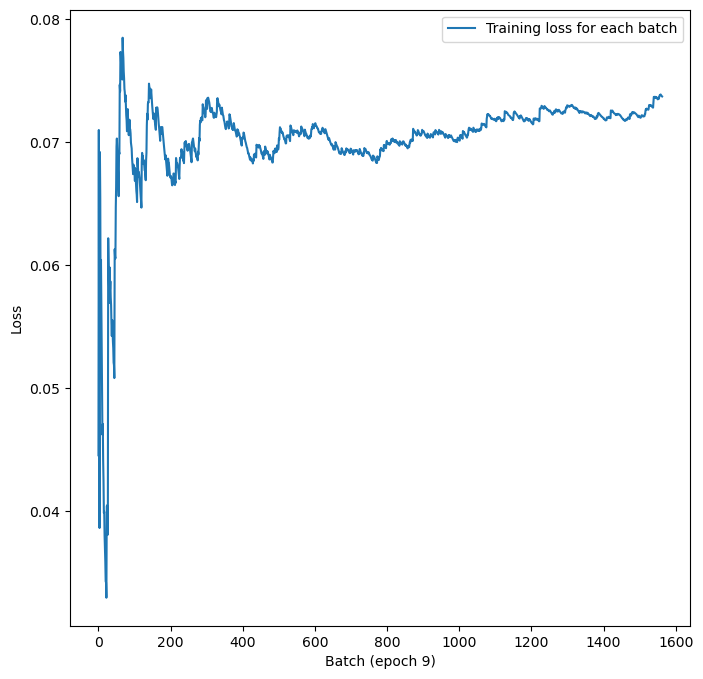

In [39]:
model = get_mnist_model()

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# use our own callback to get plots of per batch loss each epoch.
model.fit(train_images, train_labels,
          epochs=10,
          callbacks=[LossHistory()],
          validation_data=(val_images, val_labels))

![The loss per batch for last epoch of training](../figures/plot_at_epoch_0.png)

Note that internally epochs are numbered using 0 based indexing, so the figures are named
`plot_at_epoch_0` through `plot_at_epoch_9`.  The callback used by `fit()` adds one so refers
to these as epochs 1-10.  You should find all of the plots generated in the `../figures` subdirectory of the project.  

### 7.3.4 Monitoring and visualization of training with TensorBoard

To do good research or develop good models, you need rich, frequent feedback about
what’s going on inside your models during your experiments.  The TensorBoard
browser-based monitoring tool is meant to help you more quickly evaluate
results and performance from training runs of Keras deep learning models.

TensorBoard (www.tensorflow.org/tensorboard) is a browser-based application that
you can run locally. It’s the best way to monitor everything that goes on inside your
model during training. With TensorBoard, you can

- Visually monitor metrics during training
- Visualize your model architecture
- Visualize histograms of activations and gradients
- Explore embeddings in 3D

The easiest way to use TensorBoard with a Keras model and the `fit()` method is to
use the `keras.callbacks.TensorBoard` callback.  In the simplest case, just specify where you
want the callback to write logs, and you are ready to go:

In [40]:
model = get_mnist_model()

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# ask for log files to be gathered in the ../logs subdirectory of project
tensorboard = keras.callbacks.TensorBoard(
    log_dir="../logs",)

model.fit(train_images, train_labels,
          epochs=10,
          validation_data=(val_images, val_labels),
          callbacks=[tensorboard])


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8657 - loss: 0.4436 - val_accuracy: 0.9566 - val_loss: 0.1504
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9524 - loss: 0.1612 - val_accuracy: 0.9687 - val_loss: 0.1057
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9619 - loss: 0.1301 - val_accuracy: 0.9725 - val_loss: 0.1051
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9688 - loss: 0.1119 - val_accuracy: 0.9745 - val_loss: 0.0949
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9719 - loss: 0.0975 - val_accuracy: 0.9754 - val_loss: 0.0983
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9737 - loss: 0.0959 - val_accuracy: 0.9771 - val_loss: 0.0938
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9761 - loss: 0.0863 - val_accuracy: 0.9789 - val_loss: 0.0886
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9759 - loss: 0.0838 - 

Once the model starts running, it will write logs at the target location.  You can launch a
local TensorBoard server using the following command:

**Note**: The following shows running the tensorboard server using our classes Docker / DevContainer
setup.  Open a terminal running in your DevContainer and perform:

```
vscode ➜ /workspaces/nndl (main) $ tensorboard --logdir logs --bind_all
...
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

TensorBoard 2.19.0 at http://a95932961387:6006/ (Press CTRL+C to quit)

```

The `--bind_all` flag is needed when running from inside of a container.  If you are using an environment 
installed directly on your host system (not in a container) you probably don't need the bind all flag.

The TensorBoard server opens up its service on port 6006 by default.  In VSCode running a DevContainer
you will need to open up port 6006 by hand.  In your Terminal view, open the Ports tab and use the
"Add Port" button to open up and forward this port to your host machine.  Alternatively you can
add port 6006 to the list of `forwardedPorts` in your `devcontainer.json` file.

## 7.4 Writing your own Training and Evaluation loops

As a reminder, the contents of a typical training loop for supervised learning look like this:

1. Run the forward pass (compute the model’s output) inside a gradient tape to
   obtain a loss value for the current batch of data.
2. Retrieve the gradients of the loss with regard to the model’s weights.
3. Update the model’s weights so as to lower the loss value on the current batch
   of data.

These steps are repeated for as many batches as neessary.  This is essentially what the `fit()`
method does under the hood.

In this section we look at reimplementing `fit()` from scratch, so that if needed you can add
bells and whistles or implement any training algorithm you may need to.

### 7.4.1 Training versus inference

Some Keras layers, such as the `Dropout` layer that you saw, have different behaviors during *training* and during
*inference*.  For such layers you need to set the `training=True` argument of the `call()` function when performing
the forward pass, and `training=False` during inference.  Thus generically the forward pass if we are writing it
by hand is usually something like

```python
predictions = model(inputs, training=True)
```

In addition when retrieving the gradients to perform the backward pass you should use:

```python
tape.gradients(loss, model.trainable_weights)
```

because layers and models own two kinds of weights:

- **Trainable weights** These are meant to be updated via backpropagation to minimize
  the loss of the model, such as the `Dense` layers weights and biases.
- **Non-trainable weights** These are meant to be updated during the forward pass
  by the layers that own them.

So given these ideas, a supervised-learning step in Keras ends up looking like the following:

```python
def train_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss = loss_fn(targets, predictions)
        gradients = tape.gradients(loss, model.trainable_weights)
        optimizer.apply_gradients(zip(model.trainable_weights, gradients))
```

### 7.4.2 Low-level usage of metrics

In a low-level training loop, you will probably want to leverage Keras metrics. 
To use a metric by hand, simply call `update_state(y_true, y_pred)` on the metric object
for each batch of targets and predictions, and then use `result()` to query the current metric value:

In [41]:
metric = keras.metrics.SparseCategoricalAccuracy()
targets = [0, 1, 2]
predictions = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
metric.update_state(targets, predictions)
current_result = metric.result()
print(f"result: {current_result:.2f}")


result: 1.00


You may also need to track the average of a scalar value, such as the model's loss.  You
can do this using `keras.metrics.Mean` metric:

In [42]:
values = [0, 1, 2, 3, 4]
mean_tracker = keras.metrics.Mean()
for value in values:
    mean_tracker.update_state(value)
print(f"Mean of values: {mean_tracker.result():.2f}")

Mean of values: 2.00


Remember to use `metric.reset_state()` when you want to reset the current results at the start of a training
epoch or at the start of evaluation.

### 7.4.3 A complete training and evaluation loop

As an example, lets combine the forward pass, backward pass and metrics tracking into a `fit()` like
training step function that takes a batch of data and targets and returns the logs that
would get displayed by the `fit()` progress bar.

In [43]:
model = get_mnist_model()

# prepare the loss function, optimizer and list of metrics to monitor
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.RMSprop()
metrics = [keras.metrics.SparseCategoricalAccuracy()]

# use a metrice.mean to track the loss average
loss_tracking_metric = keras.metrics.Mean()


def train_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss = loss_fn(targets, predictions)
    gradients = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    # keep track of metrics
    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs[metric.name] = metric.result()

    # keep track of the loss average
    loss_tracking_metric.update_state(loss)
    logs["loss"] = loss_tracking_metric.result()

    # return the current values of the metrics and loss
    return logs

We need to reset the state of our metrics at the start of each epoch (the above function is called to update
for each batch created during an epoch of training).

In [44]:
def reset_metrics():
    for metric in metrics:
        metric.reset_state()
        loss_tracking_metric.reset_state()

We can now lay out our complete training loop.  Not that we use a `tf.data.Dataset` object to turn
our NumPy data into an iterator that iterates over the data in batches of size 32.

In [45]:
training_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, train_labels))
training_dataset = training_dataset.batch(32)
epochs = 3

for epoch in range(epochs):
    reset_metrics()
    for inputs_batch, targets_batch in training_dataset:
        logs = train_step(inputs_batch, targets_batch)
    print(f"Results at the end of epoch {epoch}")
    for key, value in logs.items():
        print(f"...{key}: {value:.4f}")

Results at the end of epoch 0
...sparse_categorical_accuracy: 0.9135
...loss: 0.2916
Results at the end of epoch 1
...sparse_categorical_accuracy: 0.9537
...loss: 0.1629
Results at the end of epoch 2
...sparse_categorical_accuracy: 0.9633
...loss: 0.1321


And to complete the by hand example, similarly we need an evaluation loop.  A simple loop that repeatedly
calls a `test_step()` function, which processes a single batch of data.  

In [46]:
# this is really a subset of the train_step, just omitting the
# calculation of gradients and weight update.  Notice that
# training=false
def test_step(inputs, targets):
    predictions = model(inputs, training=False)
    loss = loss_fn(targets, predictions)
    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs["val_" + metric.name] = metric.result()
    loss_tracking_metric.update_state(loss)
    logs["val_loss"] = loss_tracking_metric.result()
    return logs


val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_dataset = val_dataset.batch(32)
reset_metrics()

for inputs_batch, targets_batch in val_dataset:
    logs = test_step(inputs_batch, targets_batch)
print("Evaluation results:")
for key, value in logs.items():
    print(f"...{key}: {value:.4f}")

Evaluation results:
...val_sparse_categorical_accuracy: 0.9669
...val_loss: 0.1181


You may notice that performance is pretty bad for the previous examples.  `fit()` and `evaluate()` support many more fitures,
including large-scale distributed computation, which requires a bit more work.

### 7.4.4 Make it fast with tf.function

You may have noticed that your custom loops are running significantly slower than the
built-in fit() and evaluate(), despite implementing essentially the same logic.
That’s because, by default, TensorFlow code is executed line by line, *eagerly*,
e.g. it is interpreted.

It is more performant to **cmpile** your TensorFlow code into a
**computation graph** that can be globally optimized in a way that code 
interpreted line by line cannot.  Luckily we can simply add the `@tf.function`
decorator to any function to indicate this should be done.

In [47]:
# redo the evaluation loop, showing effect of compiling the function using tf.function decorator
@tf.function
def test_step(inputs, targets):
    predictions = model(inputs, training=False)
    loss = loss_fn(targets, predictions)
    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs["val_" + metric.name] = metric.result()
    loss_tracking_metric.update_state(loss)
    logs["val_loss"] = loss_tracking_metric.result()
    return logs

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_dataset = val_dataset.batch(32)
reset_metrics()

for inputs_batch, targets_batch in val_dataset:
    logs = test_step(inputs_batch, targets_batch)
print("Evaluation results:")
for key, value in logs.items():
    print(f"...{key}: {value:.4f}")

Evaluation results:
...val_sparse_categorical_accuracy: 0.9669
...val_loss: 0.1181


On my system, this goes from taking many seconds to run, to returning almost immediately
when add in the compile decorator.

Remember, while you are debugging your code, prefer running it eagerly, without
any @tf.function decorator. It’s easier to track bugs this way. Once your code is working
and you want to make it fast, add a @tf.function decorator to your training step
and your evaluation step—or any other performance-critical function.

### 7.4.5 Leveraging `fit()` with a custom training loop

What if you need a custom training algorithm, but you still want to leverage the
power of the built-in Keras training logic? There’s actually a middle ground between
fit() and a training loop written from scratch: you can provide a custom training
step function and let the framework do the rest.

Here is a simple example

- We create a new class that subclasses keras.Model.
- We override the method train_step(self, data).
- We implement a metrics property that tracks the model’s Metric instances.

In [48]:
# the loss_tracker will be used to track the average of per-batch losses during training
loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

# our own Model so can override train_step
class CustomModel(keras.Model):

    # override the train_step method, this is basically the same as was developed
    # in previous example
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            # but using self(inputs, training=True) instead of model() since our
            # model is this class instance itself
            predictions = self(inputs, training=True)
            loss = loss_fn(targets, predictions)

        gradients = tape.gradient(loss, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

        # update the loss tracker metric that tracks the average of the loss
        loss_tracker.update_state(loss)
        # return the average loss so far by querying the loss tracker metric
        return {"loss": loss_tracker.result()}

    # any metric you would like to reset across epochs should be listed here
    @property
    def metrics(self):
        return [loss_tracker]

We can now instantiate our custom model, compile it, and train it using `fit()` as usual

A couple of points to note:

- This pattern does not prevent you from building models with the Functional
  API. You can do this whether you’re building Sequential models, Functional
   API models, or subclassed models.
- You don’t need to use a @tf.function decorator when you override train_
  step—the framework does it for you.

Now what about metrics and what about configuring the loss via `compile()?

After calling `compile()` you get access to the following:

- **self.compiled_loss** The loss function you passed to compile().
- **self.compiled_metrics** A wrapper for the list of metrics you passed, which
  allows you to call self.compiled_metrics.update_state() to update all of
  your metrics at once.
- **self.metrics** The actual list of metrics you passed to compile(). Note that it
  also includes a metric that tracks the loss, similar to what we did manually with
  our loss_tracking_metric earlier.

We can thus modify to more tightly integreate with the Keras workflow:

In [49]:
class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            # compute the loss via the one given to the compile() method
            loss = self.compiled_loss(targets, predictions)
        gradients = tape.gradient(loss, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))
        # likewise use the metrics from compile() and update
        self.compiled_metrics.update_state(targets, predictions)
        # return a dict mapping metric names to their current values
        return {m.name: m.result() for m in self.metrics}

Let's try it

# Chapter Summary

Things to remember about advanced features of working with the Keras API

<font color='blue'>

- Keras offers a spectrum of different workflows.  They all should smoothly inter-operate together.
- You can build models via the `Sequential` class, via the Functional API, or by
  subclassing the `Model` class.  Most of the time you'll be using the Function API as it gives a
  good balance between convenience and ability to modify for specific needs.
- The simplest way to train and evaluate a model is via the default fit() and
  evaluate() methods.
- Keras callbacks provide a simple way to monitor models during your call to
  fit() and automatically take action based on the state of the model.
- You can also fully take control of what fit() does by overriding the train_
  step() method.
